### Import library, path dan grayscale

Berhasil memuat gambar: otakmanusia_penampangwarnapalsu.jpg


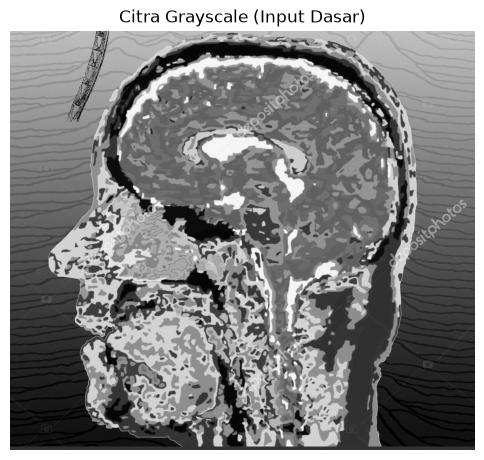

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- KONFIGURASI PATH ---
# Path Gambar Input
IMAGE_PATH = r"D:\Semester 5\Data Citra\Kuliah-Data-Citra\Dataset\otakmanusia_penampangwarnapalsu.jpg"

# Path Folder Output Hasil
OUTPUT_DIR = r"D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil"

# Buat folder Hasil jika belum ada
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Ambil nama file asli
filename = os.path.basename(IMAGE_PATH)

# Baca Gambar Input
img1 = cv2.imread(IMAGE_PATH)

if img1 is None:
    print(f"Gagal membaca gambar dari: {IMAGE_PATH}")
else:
    print(f"Berhasil memuat gambar: {filename}")
    
    a, b, _ = img1.shape
    
    # Mengubah citra RGB menjadi grayscale (Pixel-by-Pixel)
    img_gray = np.zeros((a, b), dtype=np.uint8)
    for i in range(a):
        for j in range(b):
            B = int(img1[i, j, 0])
            G = int(img1[i, j, 1])
            R = int(img1[i, j, 2])

            img_gray[i, j] = int(round(0.114 * B + 0.587 * G + 0.299 * R))

    # Tampilkan Gambar Grayscale Dasar
    plt.figure(figsize=(6, 6))
    plt.imshow(img_gray, cmap="gray")
    plt.title("Citra Grayscale (Input Dasar)")
    plt.axis("off")
    plt.show()

## Invers Citra (Citra Negative)

Selesai! Disimpan ke: D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil\Invers_otakmanusia_penampangwarnapalsu.jpg


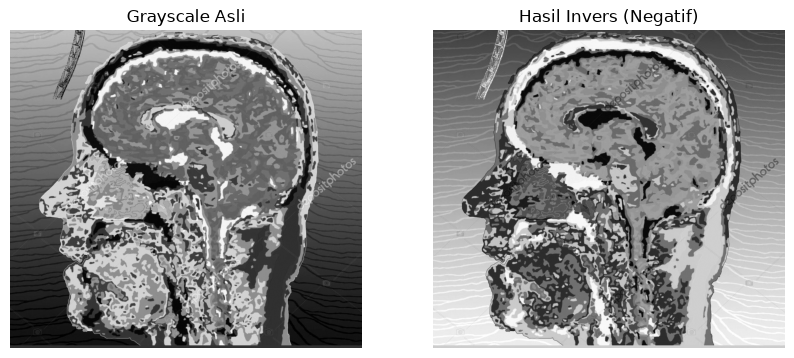

In [2]:
# Membuat citra hasil invers
img_invers = np.zeros((a, b), dtype=np.uint8)

# Proses Pixel-by-Pixel
for i in range(a):
    for j in range(b):
        r = int(img_gray[i, j])
        img_invers[i, j] = 255 - r

# Simpan Hasil
save_path_invers = os.path.join(OUTPUT_DIR, f"Invers_{filename}")
cv2.imwrite(save_path_invers, img_invers)
print(f"Selesai! Disimpan ke: {save_path_invers}")

# Tampilkan Perbandingan
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_invers, cmap="gray")
plt.title("Hasil Invers (Negatif)")
plt.axis("off")

plt.show()

## Log transformation

Selesai! Disimpan ke: D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil\Log_otakmanusia_penampangwarnapalsu.jpg


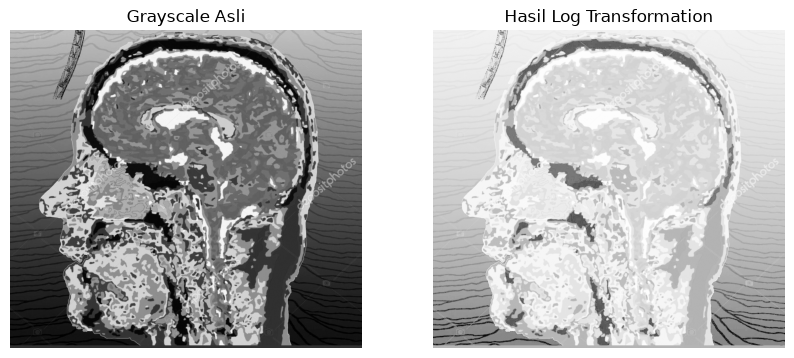

In [3]:
# Menentukan konstanta c agar rentang nilai output tetap 0-255
c = 255 / np.log(1 + 255)

# Membuat citra hasil log transformation
img_log = np.zeros((a, b), dtype=np.uint8)

# Proses Pixel-by-Pixel
for i in range(a):
    for j in range(b):
        r = int(img_gray[i, j])
        s = c * np.log(1 + r)
        img_log[i, j] = int(round(s))

# Simpan Hasil
save_path_log = os.path.join(OUTPUT_DIR, f"Log_{filename}")
cv2.imwrite(save_path_log, img_log)
print(f"Selesai! Disimpan ke: {save_path_log}")

# Tampilkan Perbandingan
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_log, cmap="gray")
plt.title("Hasil Log Transformation")
plt.axis("off")

plt.show()